# Lab 2 — Segmentation des districts par K-means

**Machine Learning II (ADIF84) — Projet : tableau de bord des autobus scolaires électriques aux États-Unis**

## 1. Compréhension du problème métier

**Objectif business.** Identifier des **groupes (segments) de districts scolaires** parmi ceux déjà engagés dans les bus électriques, afin de **mieux cibler une démarche commerciale / publicitaire**. Le décideur visé est une société de vente de bus électriques.

**Question à laquelle on répond :**
> « Existe-t-il des profils-types de districts engagés, vers lesquels adapter un discours commercial distinct ? »

**Type de tâche (cf. chapitre 2 — Cluster Analysis).** Il s'agit de **clustering** : une tâche **descriptive** et **non supervisée** (il n'y a pas de "bonne réponse" à prédire ; on cherche une structure cachée dans les données).

**Données utilisées.** On se restreint aux districts **déjà engagés** (`0a. Has committed ESBs? = yes`) et à 4 variables socio-économiques :
- `3i. Percent of fleet that is electric` — niveau d'électrification déjà atteint
- `4b. Number of students in district` — taille du district
- `4e. % students eligible for free/reduced lunch` — précarité scolaire
- `4g. Percent of population below poverty level` — pauvreté


In [1]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

## 2. Compréhension des données

On charge la source officielle (*Dataset of U.S. Electric School Bus Adoption*, WRI), feuille **« District-level data »**, et on filtre les districts **engagés**. On explore ensuite les 4 variables retenues : valeurs manquantes, statistiques et distributions.


In [2]:
# =========================
# CHARGEMENT + FILTRAGE DES DISTRICTS ENGAGÉS
# =========================
path = "../_original_dataset/electric_school_bus_adoption_dataset_v8_2024-08Aug/ESB_adoption_dataset_v8_update_august_2024.xlsx"

district = pd.read_excel(path, sheet_name="1. District-level data")
print("Dataset complet :", district.shape)

# On ne garde que les districts DÉJÀ ENGAGÉS (committed = yes)
district = district[district["0a. Has committed ESBs?"].astype(str).str.lower() == "yes"]
print("Districts engagés :", district.shape[0])

features = [
    '3i. Percent of fleet that is electric',
    '4b. Number of students in district',
    '4e. Percentage of students in district eligible for free or reduced price lunch',
    '4g. Percent of population below the poverty level'
]

# .copy() explicite => évite le SettingWithCopyWarning
df_filtre = district[features].copy()
df_filtre.head()

Dataset complet : (19516, 91)
Districts engagés : 1524


,3i. Percent of fleet that is electric,4b. Number of students in district,4e. Percentage of students in district eligible for free or reduced price lunch,4g. Percent of population below the poverty level
146,0.275362,5900.0,0.773390,0.208
147,0.088757,21130.0,0.825793,0.255
148,0.056604,1784.0,0.740471,0.169
149,1.000000,1476.0,0.773035,0.196
150,0.181818,3515.0,0.697582,0.225


In [3]:
# =========================
# EXPLORATION : valeurs manquantes + statistiques
# =========================
print("Pourcentage de valeurs manquantes par variable :")
print((df_filtre.isna().mean() * 100).round(2))

print("\nStatistiques descriptives :")
df_filtre.describe().round(3).T

Pourcentage de valeurs manquantes par variable :
3i. Percent of fleet that is electric                                              19.29
4b. Number of students in district                                                  3.35
4e. Percentage of students in district eligible for free or reduced price lunch     4.27
4g. Percent of population below the poverty level                                  12.27
dtype: float64

Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
3i. Percent of fleet that is electric,1230.0,0.256,0.818,0.000,0.042,0.125,0.286,23.000
4b. Number of students in district,1473.0,10488.711,28347.765,0.000,759.000,2663.000,8820.000,427795.000
4e. Percentage of students in district eligible for free or reduced price lunch,1459.0,0.526,0.285,0.000,0.328,0.542,0.745,1.002
4g. Percent of population below the poverty level,1337.0,0.138,0.073,0.002,0.081,0.129,0.179,0.474


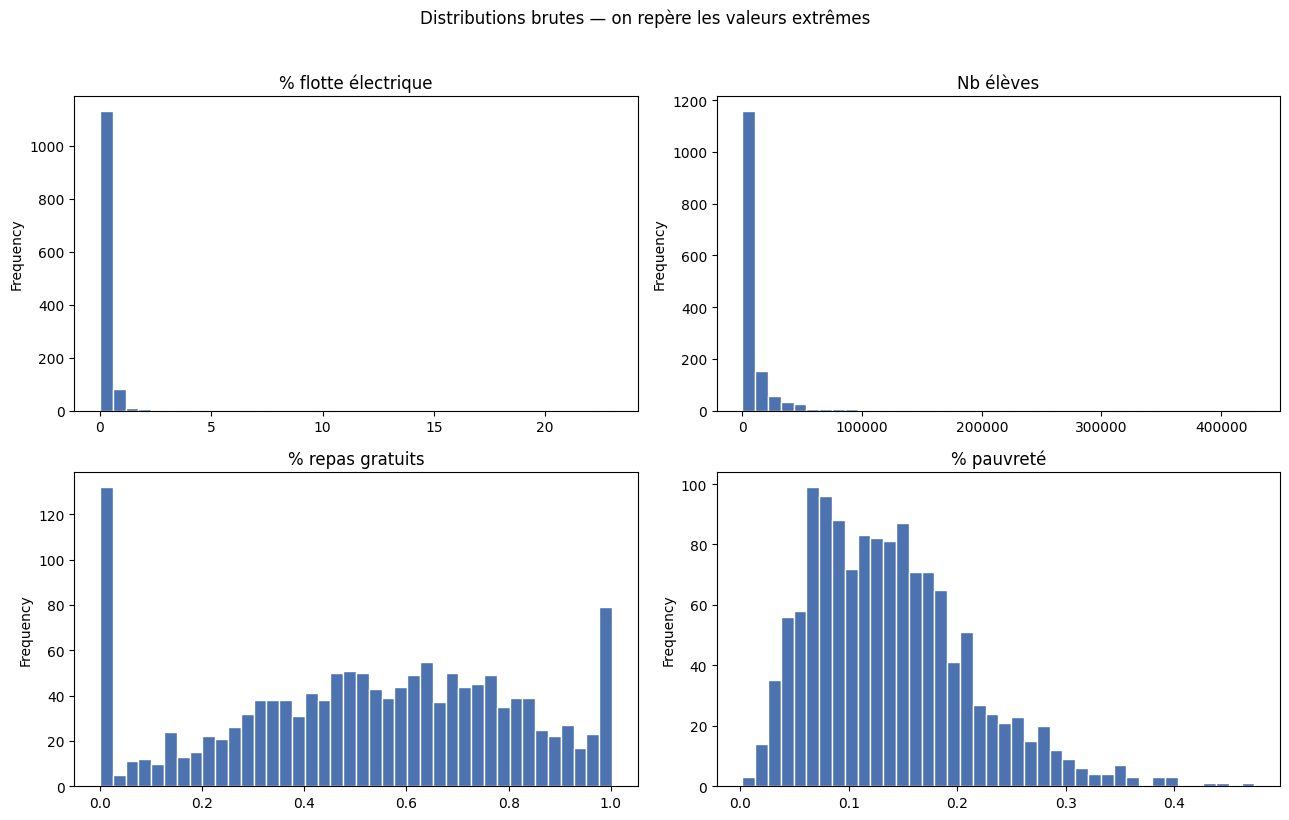

Districts avec '% flotte électrique' > 100 % (aberrant) : 22
Valeur max observée : 23.0 (soit 2300 %)


In [4]:
# =========================
# DISTRIBUTIONS DES 4 VARIABLES (avant nettoyage)
# =========================
noms_courts = {
    '3i. Percent of fleet that is electric': '% flotte électrique',
    '4b. Number of students in district': 'Nb élèves',
    '4e. Percentage of students in district eligible for free or reduced price lunch': '% repas gratuits',
    '4g. Percent of population below the poverty level': '% pauvreté'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), features):
    df_filtre[col].plot(kind='hist', bins=40, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(noms_courts[col])
    ax.set_xlabel("")
plt.suptitle("Distributions brutes — on repère les valeurs extrêmes", y=1.02)
plt.tight_layout()
plt.show()

# Mise en évidence des valeurs aberrantes : un pourcentage ne peut pas dépasser 1 (100 %)
col_elec = '3i. Percent of fleet that is electric'
n_aberrant = (df_filtre[col_elec] > 1).sum()
print(f"Districts avec '% flotte électrique' > 100 % (aberrant) : {n_aberrant}")
print("Valeur max observée :", round(df_filtre[col_elec].max(), 2), "(soit", round(df_filtre[col_elec].max()*100), "%)")

## 3. Préparation des données d'entraînement

Trois étapes, dans cet ordre :

1. **Correction des valeurs aberrantes** : la variable `% flotte électrique` contient des valeurs > 100 % (jusqu'à 2300 %), physiquement impossibles. On les **plafonne à 1.0 (100 %)**. *Justification* : K-means est très sensible aux valeurs extrêmes (il minimise des distances au carré) — un seul point aberrant peut accaparer un cluster entier.
2. **Imputation des valeurs manquantes** par la **médiane** (robuste aux extrêmes, contrairement à la moyenne).
3. **Standardisation** (`StandardScaler`) : indispensable pour K-means, car il repose sur des **distances**. Sans elle, `Nb élèves` (échelle de milliers) écraserait les variables en pourcentage (échelle 0–1).

> ⚠️ **Deux limites assumées :**
> - **`% flotte électrique` a 19 % de valeurs manquantes**, imputées par la médiane. C'est beaucoup (≈ 1 district sur 5) : cette variable est donc à interpréter avec prudence.
> - On **conserve** les valeurs extrêmes *légitimes* (ex. `Nb élèves` jusqu'à +15 σ pour les méga-districts comme New York ou Los Angeles) : ce ne sont pas des erreurs mais de vrais grands districts. Ils formeront naturellement un cluster à part — assumé comme un **segment « très grands districts »**, pas comme du bruit.

Le jeu de données préparé est exporté en `clustering.csv` (livrable « fichier des données d'entraînement »), et sert aussi d'entrée au TP3 (clustering hiérarchique).


In [5]:
# =========================
# 1) CORRECTION DES VALEURS ABERRANTES
# =========================
df_filtre[col_elec] = df_filtre[col_elec].clip(upper=1.0)

# =========================
# 2) IMPUTATION (médiane)
# =========================
for col in features:
    df_filtre[col] = df_filtre[col].fillna(df_filtre[col].median())

print("Valeurs manquantes restantes :", int(df_filtre.isna().sum().sum()))
print("Max '% flotte électrique' après plafonnement :", df_filtre[col_elec].max())

# =========================
# 3) STANDARDISATION
# =========================
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtre),
    columns=features,
    index=df_filtre.index
)

# Export du jeu d'entraînement (livrable + entrée du TP3)
df_scaled.to_csv('clustering.csv', index=False)
print("clustering.csv exporté :", df_scaled.shape)
df_scaled.describe().round(2).T[['mean', 'std', 'min', 'max']]

Valeurs manquantes restantes : 0
Max '% flotte électrique' après plafonnement : 1.0
clustering.csv exporté : (1524, 4)


,mean,std,min,max
3i. Percent of fleet that is electric,0.0,1.0,-0.91,3.82
4b. Number of students in district,-0.0,1.0,-0.37,14.97
4e. Percentage of students in district eligible for free or reduced price lunch,-0.0,1.0,-1.89,1.71
4g. Percent of population below the poverty level,-0.0,1.0,-1.97,4.92


## 4. Choix et réglage fin du modèle (K-means)

**Le K-means en bref.** L'algorithme partitionne les districts en **K groupes** : il place K centres, affecte chaque point au centre le plus proche, recalcule les centres, et recommence jusqu'à stabilisation. **L'hyperparamètre principal est K** (le nombre de clusters), qu'il faut choisir.

**Deux outils pour choisir K :**
- **Méthode du coude (elbow)** : on trace l'**inertie** (somme des distances intra-cluster) en fonction de K. Elle décroît toujours, mais on cherche le « coude » où le gain ralentit.
- **Score de silhouette** : mesure si les points sont bien dans leur cluster (proche des leurs, loin des autres). Varie de −1 (mauvais) à +1 (excellent) ; plus c'est haut, mieux c'est.

On teste aussi le paramètre `init` (`k-means++` vs `random`) qui contrôle l'initialisation des centres.


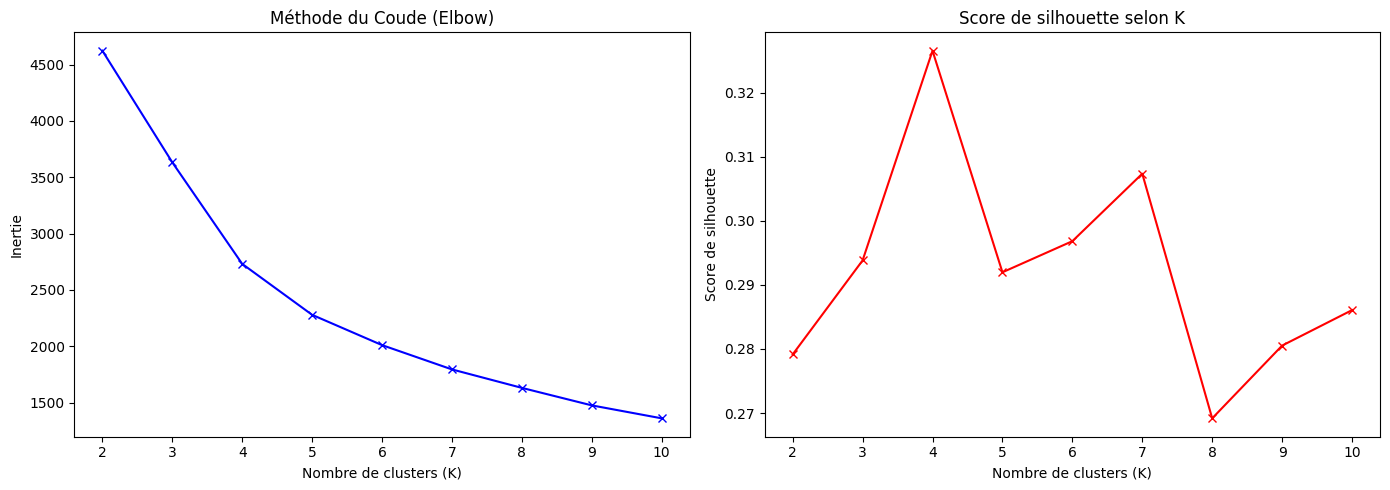

  K=2 : silhouette = 0.2791
  K=3 : silhouette = 0.2938
  K=4 : silhouette = 0.3266
  K=5 : silhouette = 0.2920
  K=6 : silhouette = 0.2968
  K=7 : silhouette = 0.3074
  K=8 : silhouette = 0.2692
  K=9 : silhouette = 0.2805
  K=10 : silhouette = 0.2861

Interprétation :
 - Coude (inertie) : la décroissance ralentit nettement vers K=3-4 (le "coude").
 - Silhouette : maximale à K=4.
 Les deux critères convergent vers un petit nombre de clusters (3 ou 4).
 On affine ce choix avec la grille K x init ci-dessous, puis par le sens métier.



In [6]:
# =========================
# MÉTHODE DU COUDE + SILHOUETTE (K de 2 à 10)
# =========================
inerties = []
scores_silhouette = []
gamme_k = range(2, 11)

for k in gamme_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(df_scaled)
    inerties.append(km.inertia_)
    scores_silhouette.append(silhouette_score(df_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(gamme_k, inerties, 'bx-')
ax1.set_xlabel('Nombre de clusters (K)'); ax1.set_ylabel('Inertie')
ax1.set_title('Méthode du Coude (Elbow)')

ax2.plot(gamme_k, scores_silhouette, 'rx-')
ax2.set_xlabel('Nombre de clusters (K)'); ax2.set_ylabel('Score de silhouette')
ax2.set_title('Score de silhouette selon K')
plt.tight_layout()
plt.show()

for k, s in zip(gamme_k, scores_silhouette):
    print(f"  K={k} : silhouette = {s:.4f}")

# --- Lecture des deux graphes ---
k_best_sil = list(gamme_k)[int(np.argmax(scores_silhouette))]
print(f"""
Interprétation :
 - Coude (inertie) : la décroissance ralentit nettement vers K=3-4 (le "coude").
 - Silhouette : maximale à K={k_best_sil}.
 Les deux critères convergent vers un petit nombre de clusters (3 ou 4).
 On affine ce choix avec la grille K x init ci-dessous, puis par le sens métier.
""")

In [7]:
# =========================
# RÉGLAGE FIN : grille (K x init) comparée par silhouette
# =========================
liste_k = [2, 3, 4, 5, 6, 7, 8]
liste_init = ['k-means++', 'random']

resultats = []
for k in liste_k:
    for mode_init in liste_init:
        km = KMeans(n_clusters=k, init=mode_init, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(df_scaled)
        resultats.append({
            'K': k,
            'init': mode_init,
            'Silhouette': silhouette_score(df_scaled, labels),
            'Inertie': km.inertia_
        })

df_tuning = pd.DataFrame(resultats).sort_values('Silhouette', ascending=False).reset_index(drop=True)
print("Top des combinaisons (triées par silhouette) :")
print(df_tuning.round(4).to_string(index=False))

# --- Interprétation : pourquoi K=4 ? ---
print("""
Lecture :
 - K=4 a la MEILLEURE silhouette (~0.327), nettement devant les autres.
 - K=7 arrive 2e (~0.307) mais 7 segments commerciaux seraient peu lisibles
   et peu actionnables pour le décideur (principe de parcimonie).
 - Le coude (graphe précédent) fléchit autour de K=3-4.
 => K=4 réunit le meilleur score ET un nombre de segments exploitable.
    On vérifie ci-dessous qu'il a aussi le meilleur SENS MÉTIER (vs K=3).
""")

Top des combinaisons (triées par silhouette) :
 K      init  Silhouette   Inertie
 4    random      0.3267 2731.4686
 4 k-means++      0.3266 2731.4908
 7 k-means++      0.3074 1795.5608
 7    random      0.2975 1841.2960
 6 k-means++      0.2968 2011.1375
 6    random      0.2968 2011.1375
 3 k-means++      0.2938 3632.3503
 3    random      0.2937 3632.3702
 5 k-means++      0.2920 2279.7052
 5    random      0.2920 2279.7052
 2 k-means++      0.2791 4622.2950
 2    random      0.2791 4622.2889
 8 k-means++      0.2692 1631.8280
 8    random      0.2689 1631.7711

Lecture :
 - K=4 a la MEILLEURE silhouette (~0.327), nettement devant les autres.
 - K=7 arrive 2e (~0.307) mais 7 segments commerciaux seraient peu lisibles
   et peu actionnables pour le décideur (principe de parcimonie).
 - Le coude (graphe précédent) fléchit autour de K=3-4.
 => K=4 réunit le meilleur score ET un nombre de segments exploitable.
    On vérifie ci-dessous qu'il a aussi le meilleur SENS MÉTIER (vs K=3).



## 5. Comparaison des profils : K=3 vs K=4

Le score de silhouette ne suffit pas à trancher (K=3 et K=4 sont proches). En clustering, **le vrai juge est le sens métier** : un bon K produit des groupes **interprétables et actionnables**.

On compare donc les **profils** des clusters pour K=3 et K=4. Les valeurs sont en **z-score** (données standardisées) : une valeur **positive** = au-dessus de la moyenne, **négative** = en dessous. Cela permet de caractériser chaque groupe d'un coup d'œil.


In [8]:
# =========================
# PROFILS DES CLUSTERS POUR K=3 ET K=4 (avec étiquette métier)
# =========================
def etiquette(row):
    """Déduit un nom de segment à partir du profil (z-scores)."""
    if row['Nb élèves'] > 2:
        return "Très grands districts"
    if row['% flotte électrique'] > 1:
        return "Pionniers (forte électrification)"
    if row['% pauvreté'] > 0.3 or row['% repas gratuits'] > 0.3:
        return "Défavorisés"
    return "Aisés"

def profils(k):
    km = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(df_scaled)
    prof = df_scaled.copy()
    prof['cluster'] = labels
    moy = prof.groupby('cluster').mean().rename(columns=noms_courts)
    moy.insert(0, 'taille', prof['cluster'].value_counts().sort_index().values)
    moy.insert(1, 'segment', moy.apply(etiquette, axis=1))
    sil = silhouette_score(df_scaled, labels)
    return moy.round(2), sil, labels

for k in [3, 4]:
    table, sil, _ = profils(k)
    print(f"\n===== K = {k}  (silhouette globale = {sil:.3f}) =====")
    print(table.to_string())


===== K = 3  (silhouette globale = 0.294) =====
         taille                segment  % flotte électrique  Nb élèves  % repas gratuits  % pauvreté
cluster                                                                                             
0           689            Défavorisés                 0.17      -0.09              0.81        0.67
1           814                  Aisés                -0.13      -0.10             -0.70       -0.57
2            21  Très grands districts                -0.61       6.84              0.30        0.19



===== K = 4  (silhouette globale = 0.327) =====
         taille                            segment  % flotte électrique  Nb élèves  % repas gratuits  % pauvreté
cluster                                                                                                         
0           165  Pionniers (forte électrification)                 2.35      -0.21              0.06       -0.08
1           734                              Aisés                -0.33      -0.10             -0.71       -0.56
2            21              Très grands districts                -0.61       6.84              0.30        0.19
3           604                        Défavorisés                -0.22      -0.06              0.84        0.70


## 6. Aller plus loin : K-means est-il le bon algorithme ? (bonus)

Le sujet impose K-means, mais le critère **B202** demande de *justifier* le choix de l'outil. Pour cela, on **compare K-means à un autre algorithme de clustering** : le **clustering agglomératif (hiérarchique)** avec critère de Ward — qui sera approfondi au TP3.

Deux métriques internes (pas besoin de labels) :
- **Silhouette** : plus haut = mieux.
- **Davies-Bouldin** : plus **bas** = mieux (mesure le chevauchement entre clusters).

L'objectif est de vérifier que K-means n'est pas un mauvais choix par défaut.


In [9]:
# =========================
# COMPARAISON K-MEANS vs CLUSTERING AGGLOMÉRATIF (K=3 et K=4)
# =========================
comparaison = []
for k in [3, 4]:
    # K-means
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(df_scaled)
    comparaison.append({
        'Algorithme': 'K-means', 'K': k,
        'Silhouette': silhouette_score(df_scaled, km.labels_),
        'Davies-Bouldin': davies_bouldin_score(df_scaled, km.labels_)
    })
    # Agglomératif (Ward)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(df_scaled)
    comparaison.append({
        'Algorithme': 'Agglomératif (Ward)', 'K': k,
        'Silhouette': silhouette_score(df_scaled, agg.labels_),
        'Davies-Bouldin': davies_bouldin_score(df_scaled, agg.labels_)
    })

df_cmp = pd.DataFrame(comparaison)
print(df_cmp.round(4).to_string(index=False))

print("""
Lecture :
 - À K=4, K-means obtient la meilleure silhouette ET le meilleur Davies-Bouldin.
 - Le clustering agglomératif est très proche (2e), ce qui CONFIRME la structure
   en 4 groupes (deux algorithmes différents la retrouvent).
 => K-means est bien le choix le plus adapté ici : meilleurs scores, plus rapide,
    et clusters sphériques cohérents avec des données standardisées.
""")

         Algorithme  K  Silhouette  Davies-Bouldin
            K-means  3      0.2938          1.0961
Agglomératif (Ward)  3      0.2618          1.1826
            K-means  4      0.3266          0.9428
Agglomératif (Ward)  4      0.3024          0.9815

Lecture :
 - À K=4, K-means obtient la meilleure silhouette ET le meilleur Davies-Bouldin.
 - Le clustering agglomératif est très proche (2e), ce qui CONFIRME la structure
   en 4 groupes (deux algorithmes différents la retrouvent).
 => K-means est bien le choix le plus adapté ici : meilleurs scores, plus rapide,
    et clusters sphériques cohérents avec des données standardisées.



## 7. Modèle final et visualisation

On retient **K = 4** avec **K-means** (meilleur algorithme d'après la comparaison ci-dessus) : après correction des valeurs aberrantes, ce découpage fait apparaître un **groupe de districts "pionniers"** (forte électrification déjà réalisée) que K=3 ne distinguait pas — un segment commercialement très pertinent. On visualise les clusters en projetant les 4 dimensions sur un plan 2D via **ACP (PCA)**.


   RAPPORT K-MEANS (K = 4)
Inertie totale (intra-cluster) : 2731.49
Silhouette globale             : 0.3266
---------------------------------------------
 Cluster 0 : silhouette = 0.2803  (n=165)
 Cluster 1 : silhouette = 0.3497  (n=734)
 Cluster 2 : silhouette = 0.3716  (n=21)
 Cluster 3 : silhouette = 0.3095  (n=604)


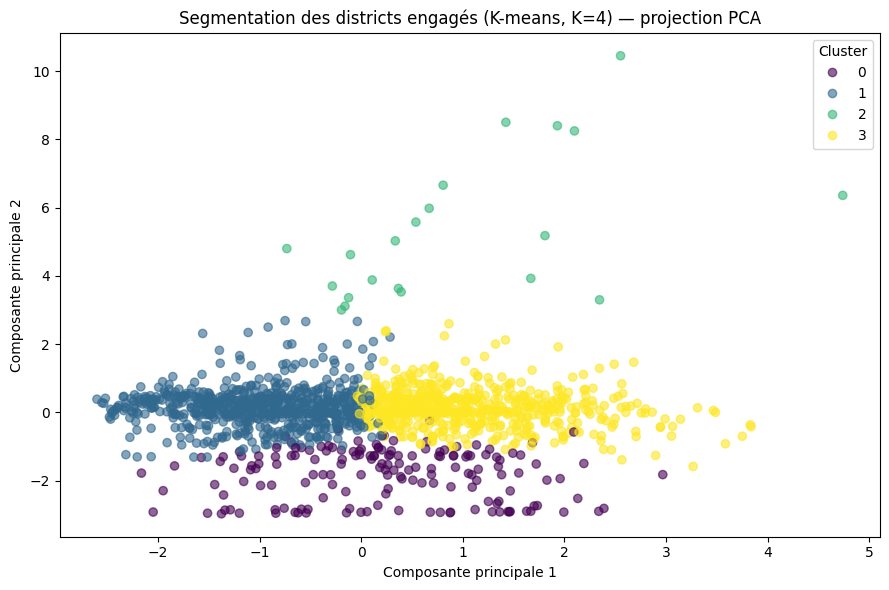

In [10]:
# =========================
# MODÈLE FINAL (K=4) + RAPPORT + VISUALISATION PCA
# =========================
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, init='k-means++', random_state=RANDOM_STATE, n_init=10)
labels = kmeans_final.fit_predict(df_scaled)

# --- Rapport d'évaluation ---
sil_global = silhouette_score(df_scaled, labels)
sil_par_point = silhouette_samples(df_scaled, labels)
print("=" * 45)
print(f"   RAPPORT K-MEANS (K = {K_FINAL})")
print("=" * 45)
print(f"Inertie totale (intra-cluster) : {kmeans_final.inertia_:.2f}")
print(f"Silhouette globale             : {sil_global:.4f}")
print("-" * 45)
for i in range(K_FINAL):
    print(f" Cluster {i} : silhouette = {sil_par_point[labels == i].mean():.4f}  (n={np.sum(labels==i)})")
print("=" * 45)

# --- Projection PCA 2D ---
X2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(df_scaled)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title(f"Segmentation des districts engagés (K-means, K={K_FINAL}) — projection PCA")
plt.tight_layout()
plt.show()

## 8. Conclusion

**Démarche.** Compréhension métier → compréhension des données (détection de valeurs aberrantes) → préparation rigoureuse (correction des aberrants, imputation médiane, standardisation) → réglage fin (coude + silhouette + grille K×init) → **choix de K par le sens métier** (comparaison des profils) → **comparaison à un autre algorithme** (agglomératif) pour valider K-means.

**Choix d'outils justifiés (B202).**
- *K-means* : algorithme de clustering simple, rapide et adapté à des groupes de forme sphérique sur peu de dimensions. **Validé empiriquement** : il bat le clustering agglomératif sur silhouette et Davies-Bouldin.
- *Standardisation* : obligatoire car K-means repose sur des distances.
- *Silhouette + coude + Davies-Bouldin* : critères complémentaires, complétés par l'interprétation métier.
- *Correction des aberrants* : sans elle, K=4 produisait un cluster d'un seul point inutile ; après correction, il révèle un vrai segment.

**Les 4 segments identifiés (interprétation métier).** À lire dans le tableau des profils K=4 :
- **"Pionniers"** (forte électrification déjà réalisée),
- **"Défavorisés"** (forte pauvreté / repas gratuits),
- **"Aisés"** (faible pauvreté),
- **"Très grands districts"** (nombre d'élèves très élevé).

**Exploitation commerciale.** Chaque segment appelle un discours distinct : aux pionniers, proposer l'extension de flotte ; aux défavorisés, mettre en avant les subventions ; aux grands districts, des offres de volume.

**Limites & pistes (B206).** Silhouette modérée (~0.33) : les groupes se chevauchent partiellement — normal sur données réelles. Le clustering agglomératif, très proche, est approfondi au **TP3**. Autres pistes : ajouter des variables (région, programmes d'aide), ou tester un clustering basé densité (DBSCAN, cf. TP5).
